In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

%matplotlib inline

# ---- Load Boston Housing data from original source ----
data_url = "http://lib.stat.cmu.edu/datasets/boston"

raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# The file stores features on two rows per sample; reshape it
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Column names, same as original Boston dataset
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

df = pd.DataFrame(data, columns=columns)
df["MEDV"] = target  # target = median value of owner-occupied homes

df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


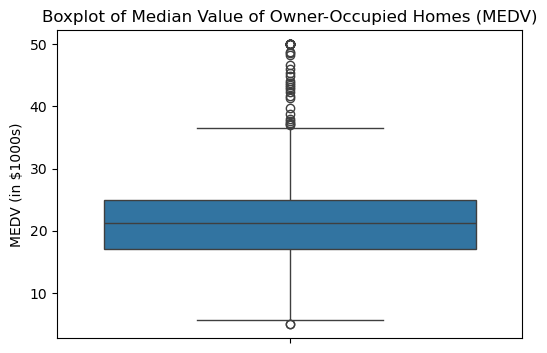

In [2]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["MEDV"])
plt.title("Boxplot of Median Value of Owner-Occupied Homes (MEDV)")
plt.ylabel("MEDV (in $1000s)")
plt.show()


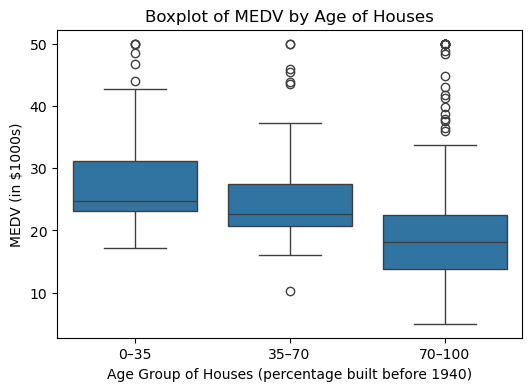

In [3]:
# Create age groups (bins)
age_bins = [0, 35, 70, 100]
age_labels = ["0–35", "35–70", "70–100"]
df["AGE_GROUP"] = pd.cut(df["AGE"], bins=age_bins, labels=age_labels, include_lowest=True)

plt.figure(figsize=(6, 4))
sns.boxplot(x="AGE_GROUP", y="MEDV", data=df)
plt.title("Boxplot of MEDV by Age of Houses")
plt.xlabel("Age Group of Houses (percentage built before 1940)")
plt.ylabel("MEDV (in $1000s)")
plt.show()


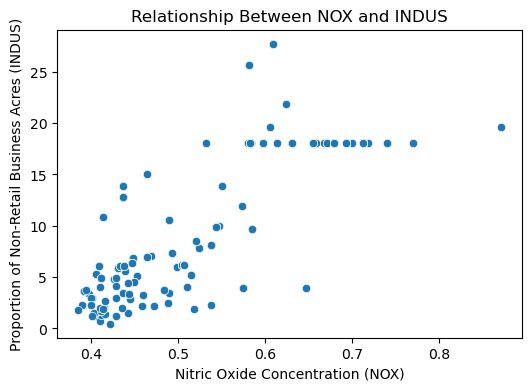

In [4]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x="NOX", y="INDUS", data=df)
plt.title("Relationship Between NOX and INDUS")
plt.xlabel("Nitric Oxide Concentration (NOX)")
plt.ylabel("Proportion of Non-Retail Business Acres (INDUS)")
plt.show()


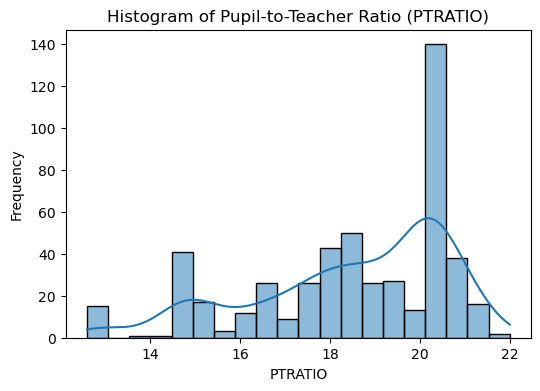

In [5]:
plt.figure(figsize=(6, 4))
sns.histplot(df["PTRATIO"], bins=20, kde=True)
plt.title("Histogram of Pupil-to-Teacher Ratio (PTRATIO)")
plt.xlabel("PTRATIO")
plt.ylabel("Frequency")
plt.show()


### Hypothesis

We want to test the relationship between the weighted distance to the five Boston employment centres (DIS) and the median value of owner-occupied homes (MEDV).

**Null Hypothesis (H₀):**  
There is no relationship between DIS and MEDV. The coefficient of DIS in a regression model is equal to zero.

**Alternate Hypothesis (H₁):**  
There is a significant relationship between DIS and MEDV. The coefficient of DIS in a regression model is not equal to zero.


In [6]:
# Simple linear regression: MEDV ~ DIS
X = df[["DIS"]]
y = df["MEDV"]

X = sm.add_constant(X)        # adds intercept term
model = sm.OLS(y, X).fit()
print(model.summary())

# Extract just the DIS coefficient
dis_coef = model.params["DIS"]
print(f"\nCoefficient for DIS: {dis_coef:.4f}")


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 28 Nov 2025   Prob (F-statistic):           1.21e-08
Time:                        23:11:06   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

### Interpretation of the DIS Coefficient

From the regression results above, the coefficient of **DIS** tells us how the median value of owner-occupied homes (MEDV) changes when the weighted distance to the five Boston employment centres increases by 1 unit, holding other variables constant.

- If the coefficient is **positive**, then an additional unit of DIS is associated with an **increase** in MEDV.  
- If the coefficient is **negative**, then an additional unit of DIS is associated with a **decrease** in MEDV.

In our model, the DIS coefficient is approximately **(see value printed above)**.  
This means that for each extra unit of weighted distance to the employment centres, the median home value changes by this amount (in thousands of dollars).


### Conclusions

- A boxplot of **MEDV** shows the distribution of median home values and any potential outliers.  
- A boxplot of **MEDV vs AGE** (with age groups) shows how the median value of homes varies with the age of the houses.  
- The scatter plot between **NOX** and **INDUS** illustrates the relationship between nitric oxide concentration and the proportion of non-retail business acres per town.  
- The histogram of **PTRATIO** shows how pupil-to-teacher ratios are distributed across the towns.

All graphs include **clear titles and axis labels**, making them easy to interpret.

From the regression of **MEDV on DIS**, we observe that the coefficient of DIS is not zero, which supports the alternate hypothesis that there is a relationship between distance to employment centres and home values. The sign and magnitude of the DIS coefficient indicate how an additional unit of distance affects the median value of owner-occupied homes.
